# Human-in-the-Loop Pattern



A human-in-the-loop pattern inserts approval checkpoints before high-risk actions.



## Stack

- Framework: LangGraph with interrupt-style approval gate

- LLM: local Ollama via `ChatOllama(model="llama3.1:latest")`

- Pattern goal: controlled execution



## When to use it

- The agent can trigger financial, legal, or customer-facing effects

- You need review, policy, or accountability

## Architecture



```mermaid

graph TD

    U[User Request] --> D[Draft Action]

    D --> H[Human Approval Gate]

    H -->|approved| E[Execute]

    H -->|rejected| S[Stop]

```

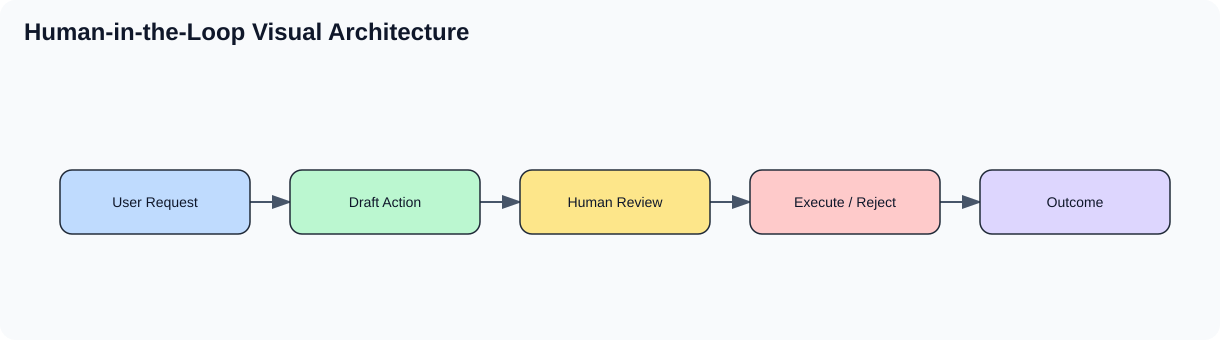

In [1]:
from visual_diagram_helper import render_svg_flow



nodes = [

    ("request", "User Request", 60, 170, "#bfdbfe"),

    ("draft", "Draft Action", 290, 170, "#bbf7d0"),

    ("review", "Human Review", 520, 170, "#fde68a"),

    ("execute", "Execute / Reject", 750, 170, "#fecaca"),

    ("outcome", "Outcome", 980, 170, "#ddd6fe"),

]

edges = [

    ("request", "draft"),

    ("draft", "review"),

    ("review", "execute"),

    ("execute", "outcome"),

]



render_svg_flow("Human-in-the-Loop Visual Architecture", nodes, edges, width=1220, height=340)

In [2]:
# Reload shared helpers so any edits to agent_patterns_common.py take effect

# without needing to restart the kernel.

import importlib

import agent_patterns_common



importlib.reload(agent_patterns_common)

print("agent_patterns_common reloaded.")

agent_patterns_common reloaded.


### Human-in-the-Loop State Graph

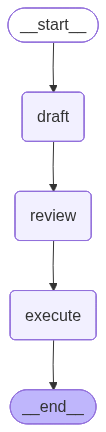

{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "Draft a cautious action plan.\nReturn EXACTLY 2 bullet points.\nEach bullet starts"}
{"level": "INFO", "event_type": "llm_invoke_success", "attempt": 1}
{"level": "INFO", "event_type": "approval_draft_ready", "request": "Issue a $750 refund to customer 12345"}
{"level": "INFO", "event_type": "human_review_complete", "reviewer": "ops_manager", "approved": true}


{'request': 'Issue a $750 refund to customer 12345',
 'draft_action': "Here is a cautious action plan:\n\n* - Verify the customer's identity and account information to ensure that the refund is being issued to the correct person.\n* - Obtain approval from a supervisor or manager before processing the refund, as this will help prevent any potential errors or discrepancies.",
 'approved': True,
 'reviewer': 'ops_manager',
 'outcome': "Approved by ops_manager and executed: Here is a cautious action plan:\n\n* - Verify the customer's identity and account information to ensure that the refund is being issued to the correct person.\n* - Obtain approval from a supervisor or manager before processing the refund, as this will help prevent any potential errors or discrepancies.",
 'history': ['Draft action created',
  'Reviewed by ops_manager',
  "Approved by ops_manager and executed: Here is a cautious action plan:\n\n* - Verify the customer's identity and account information to ensure that the

In [ ]:
from langgraph.graph import END, START, StateGraph

from agent_pattern_states import ApprovalState
from agent_patterns_common import (
    append_history,
    build_checkpointer,
    get_local_llm,
    invoke_with_retry,
    log_event,
    render_state_graph, 
)

llm = get_local_llm()

def draft_action_node(state: ApprovalState) -> ApprovalState:
    prompt = (
        "Draft a cautious action plan.\n"
        "Return EXACTLY 2 bullet points.\n"
        "Each bullet starts with '- '.\n"
        f"Request: {state['request']}"
    )
    draft_action = invoke_with_retry(llm, prompt)
    log_event("info", "approval_draft_ready", request=state["request"])
    return {
        "draft_action": draft_action,
        "history": append_history(state.get("history"), "Draft action created"),
    }

def _collect_human_decision() -> dict:
    """Prompt for reviewer identity and approval decision at runtime."""
    print("\nHuman approval required")
    reviewer = input("Reviewer name: ").strip() or "human_reviewer"

    while True:
        decision = input("Approve action? (yes/no): ").strip().lower()
        if decision in {"yes", "y"}:
            return {"approved": True, "reviewer": reviewer}
        if decision in {"no", "n"}:
            return {"approved": False, "reviewer": reviewer}
        print("Please enter 'yes' or 'no'.")

def human_review_node(state: ApprovalState) -> ApprovalState:
    decision = _collect_human_decision()
    log_event(
        "info",
        "human_review_complete",
        reviewer=decision["reviewer"],
        approved=decision["approved"],
    )
    return {
        "approved": decision["approved"],
        "reviewer": decision["reviewer"],
        "history": append_history(
            state["history"],
            f"Reviewed by {decision['reviewer']} (approved={decision['approved']})",
        ),
    }

def execute_node(state: ApprovalState) -> ApprovalState:
    if state["approved"]:
        outcome = f"Approved by {state['reviewer']} and executed: {state['draft_action']}"
    else:
        outcome = f"Rejected by {state['reviewer']}."
    return {
        "outcome": outcome,
        "history": append_history(state["history"], outcome),
    }

builder = StateGraph(ApprovalState)
builder.add_node("draft", draft_action_node)
builder.add_node("review", human_review_node)
builder.add_node("execute", execute_node)
builder.add_edge(START, "draft")
builder.add_edge("draft", "review")
builder.add_edge("review", "execute")
builder.add_edge("execute", END)

graph = builder.compile(checkpointer=build_checkpointer())
render_state_graph(graph, "Human-in-the-Loop State Graph")

result = graph.invoke(
    {
        "request": "Issue a $750 refund to customer 12345",
        "draft_action": "",
        "approved": False,
        "reviewer": "",
        "outcome": "",
        "history": [],
    },
    config={"configurable": {"thread_id": "human-in-loop-demo"}},
)

result

## Design insight



Guardrails are part of the architecture. Add the approval boundary where the real-world risk begins, not as an afterthought.